# Learn the mean of the Lorenz system 

In [2]:
using Revise                              
using LorenzParameterEstimation
using Plots, Random, Statistics, LinearAlgebra

## Visualisations

In [2]:
# Initial condition 
u0 = [1.0, 1.0, 1.0]
M  = 20_000
T  = 100.0
dt = T / M
tspan = (0.0, T)
base_params = classic_params()

trajectory = integrate(base_params, u0, (0.0, T), dt)

L63Solution{Float64, Vector{Float64}, Matrix{Float64}, L63System{Float64, Vector{Float64}}}([0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045  …  99.955, 99.96000000000001, 99.965, 99.97, 99.97500000000001, 99.98, 99.985, 99.99000000000001, 99.995, 100.0], [1.0 1.0 1.0; 1.0031933311430772 1.129839801362649 0.9920510551862709; … ; -0.9938824148762829 -1.892609128103656 16.965693824136157; -1.0388569689855993 -1.9396559790447456 16.750658939956015], L63System{Float64, Vector{Float64}}(L63Parameters{Float64}(10.0, 28.0, 2.6666666666666665, 0.0, 0.0, 0.0, 1.0), [1.0, 1.0, 1.0], (0.0, 100.0), 0.005), [-1.0388569689855993, -1.9396559790447456, 16.750658939956015], true)

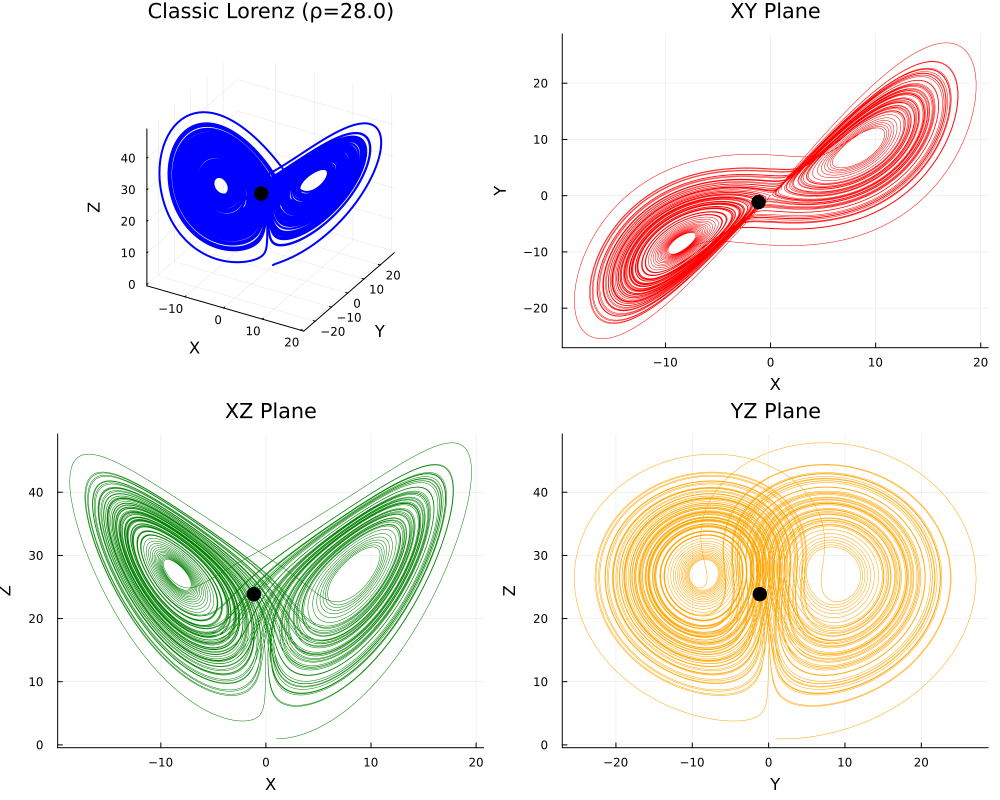

In [3]:
# Compute the mean of each coordinate
mean_x = mean(trajectory.u[:, 1])
mean_y = mean(trajectory.u[:, 2])
mean_z = mean(trajectory.u[:, 3])

# 3D trajectory plot with mean point
p1 = plot(trajectory.u[:, 1], trajectory.u[:, 2], trajectory.u[:, 3];
    title="Classic Lorenz (ρ=28.0)", xlabel="X", ylabel="Y", zlabel="Z",
    linecolor=:blue, legend=false, linewidth=2, seriestype=:path3d, size=(600, 400))
scatter!(p1, [mean_x], [mean_y], [mean_z], markersize=8, markercolor=:black, label="Mean")

# XY plane projection with mean point
p2 = plot(trajectory.u[:, 1], trajectory.u[:, 2];
    title="XY Plane", xlabel="X", ylabel="Y",
    linecolor=:red, legend=false, linewidth=0.5)
scatter!(p2, [mean_x], [mean_y], markersize=8, markercolor=:black, label="Mean")

# XZ plane projection with mean point
p3 = plot(trajectory.u[:, 1], trajectory.u[:, 3];
    title="XZ Plane", xlabel="X", ylabel="Z",
    linecolor=:green, legend=false, linewidth=0.5)
scatter!(p3, [mean_x], [mean_z], markersize=8, markercolor=:black, label="Mean")

# YZ plane projection with mean point
p4 = plot(trajectory.u[:, 2], trajectory.u[:, 3];
    title="YZ Plane", xlabel="Y", ylabel="Z",
    linecolor=:orange, legend=false, linewidth=0.5)
scatter!(p4, [mean_y], [mean_z], markersize=8, markercolor=:black, label="Mean")

# Combine all plots in a 2x2 grid
plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 800))


In [4]:
"""anim = @animate for i in 1:100:M
    plot(trajectory.u[1:i, 1], trajectory.u[1:i, 2], trajectory.u[1:i, 3];
        title="Lorenz Trajectory Evolution", xlabel="X", ylabel="Y", zlabel="Z",
        linecolor=:blue, legend=false, linewidth=1, seriestype=:path3d, size=(600, 400))
end
gif(anim, "img/lorenz_evolution.gif", fps=1)"""

"anim = @animate for i in 1:100:M\n    plot(trajectory.u[1:i, 1], trajectory.u[1:i, 2], trajectory.u[1:i, 3];\n        title=\"Lorenz Trajectory Evolution\", xlabel=\"X\", ylabel=\"Y\", zlabel=\"Z\",\n        linecolor=:blue, legend=false, linewidth=1, seriestype=:path3d, size=(600, 400))\nend\ngif(anim, \"img/lorenz_evolution.gif\", fps=1)"

## Test try

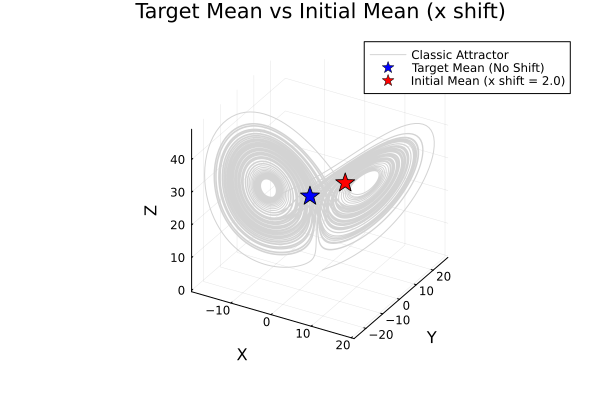

In [12]:
gr()
# Random number generator
rng = MersenneTwister(7)

# Initial condition 
u0 = [1.0, 1.0, 1.0]
M  = 20_000
T  = 100.0
dt = T / M
tspan = (0.0, T)
base_params = classic_params()

trajectory = integrate(base_params, u0, (0.0, T), dt)

mean_x = mean(trajectory.u[:, 1])
mean_y = mean(trajectory.u[:, 2])
mean_z = mean(trajectory.u[:, 3])
std_x = std(trajectory.u[:, 1])
std_y = std(trajectory.u[:, 2])
std_z = std(trajectory.u[:, 3])
init = L63Parameters(10.0, 28.0, 8/3, 2.0, 10, 0.0, 1.0)  # same σ,ρ,β but x shift = 2

# Visualize both the target (classic) mean and the initial mean (with x shift)
p = plot(
    trajectory.u[:, 1], trajectory.u[:, 2], trajectory.u[:, 3];
    linecolor=:lightgray, linewidth=1, label="Classic Attractor", seriestype=:path3d,
    title="Target Mean vs Initial Mean (x shift)", xlabel="X", ylabel="Y", zlabel="Z",
    legend=:topright, size=(600, 400)
)

# Target mean (classic)
scatter!(
    p, [mean_x], [mean_y], [mean_z];
    marker=:star, markersize=10, markercolor=:blue, label="Target Mean (No Shift)"
)

# Simulate initial shifted system
init_traj = integrate(init, u0, tspan, dt)
init_mean_x = mean(init_traj.u[:, 1])
init_mean_y = mean(init_traj.u[:, 2])
init_mean_z = mean(init_traj.u[:, 3])

# Initial mean (shifted)
scatter!(
    p, [init_mean_x], [init_mean_y], [init_mean_z];
    marker=:star, markersize=10, markercolor=:red, label="Initial Mean (x shift = 2.0)"
)

display(p)

UnifiedTrain | stats=(:mean,) | mask=(σ = false, ρ = false, β = false, x_s = true, y_s = false, z_s = false, θ = false) | dt=0.005 steps=20000 | ICs=1 | k=20000
Init  | σ=10.000000 ρ=28.000000 β=2.666667 x_s=2.000000 y_s=10.000000 z_s=0.000000 θ=1.000000
Epoch    1 | loss = 7.185283e+00 | g_norm = 1.449e+29 | σ=10.000000 ρ=28.000000 β=2.666667 x_s=1.995000 y_s=10.000000 z_s=0.000000 θ=1.000000
Epoch    2 | loss = 7.516521e+00 | g_norm = 1.938e+29 | σ=10.000000 ρ=28.000000 β=2.666667 x_s=1.990014 y_s=10.000000 z_s=0.000000 θ=1.000000
Epoch    3 | loss = 6.538945e+00 | g_norm = 2.514e+28 | σ=10.000000 ρ=28.000000 β=2.666667 x_s=1.985850 y_s=10.000000 z_s=0.000000 θ=1.000000
Epoch    4 | loss = 8.257116e+00 | g_norm = 1.650e+28 | σ=10.000000 ρ=28.000000 β=2.666667 x_s=1.982644 y_s=10.000000 z_s=0.000000 θ=1.000000
Epoch    5 | loss = 8.535624e+00 | g_norm = 3.574e+27 | σ=10.000000 ρ=28.000000 β=2.666667 x_s=1.979975 y_s=10.000000 z_s=0.000000 θ=1.000000
Epoch    6 | loss = 8.190572e+00 | 

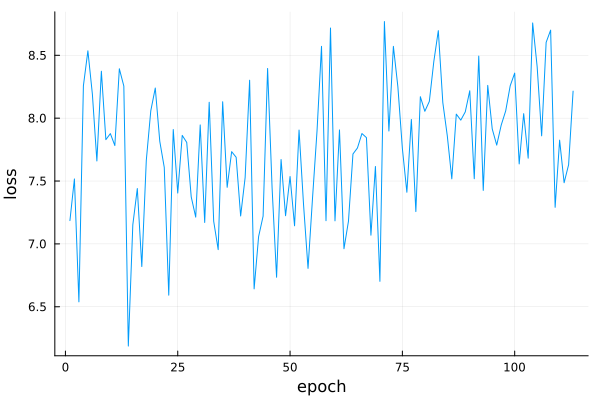

In [32]:
using Optimisers
using StatsBase

# Target "true" parameters/statistics — here we assume the classic Lorenz63 mean stats
#base_stats = evaluate_statistics(base_params; stats=(:mean,))
base_stats_mean = (mean = [mean_x, mean_y, mean_z],)
base_stats_std = (std = [std_x, std_y, std_z],)
# Train to recover the no-shift attractor means
result = train_statistics(
    init;
    target=base_stats_mean,
    stats=(:mean,),
    cfg=ClimateConfig(dt=dt, steps=20_000, samples_per_epoch=20_000, loss_mode=:rmse, rng=rng),
    base_u0=[1.0, 1.0, 1.0],
    optimizer=Optimisers.AdamW(0.005, (0.9, 0.999)),
    update_mask=(σ=false, ρ=false, β=false, x_s=true, y_s=false, z_s=false, θ=false),
    epochs=1000,
    verbose=true,
    early_stopping_patience=100,
    early_stopping_min_delta=1e-4,
    refresh=1
)

# Results
println("\nFinal parameters:")
@show result.params

println("\nFinal statistics:")
@show result.final_statistics

# Plot loss history
plot(result.loss_history, xlabel="epoch", ylabel="loss", legend=false)

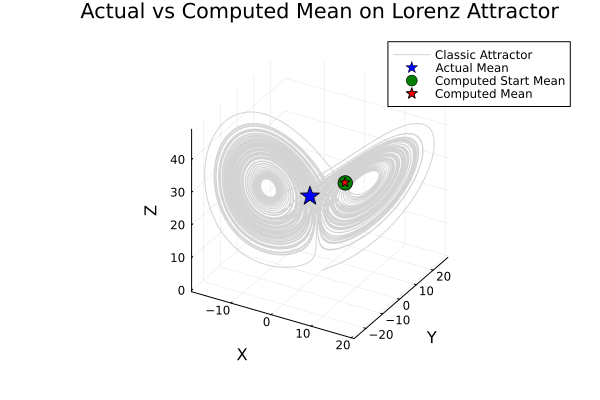

In [25]:
# Simulate classic Lorenz attractor for background
classic_traj = integrate(base_params, u0, tspan, dt)

# Extract means
actual_mean = [mean_x, mean_y, mean_z]
computed_mean = result.final_statistics.mean

# Plot classic attractor in background
plot(
    classic_traj.u[:, 1], classic_traj.u[:, 2], classic_traj.u[:, 3];
    linecolor=:lightgray, linewidth=1, label="Classic Attractor", seriestype=:path3d,
    title="Actual vs Computed Mean on Lorenz Attractor",
    xlabel="X", ylabel="Y", zlabel="Z",
    legend=:topright, size=(600, 400)
)
# Overlay actual mean
scatter!(
    [actual_mean[1]], [actual_mean[2]], [actual_mean[3]];
    marker=:star, markersize=10, markercolor=:blue, label="Actual Mean"
)

# Overlay computed starting mean (mean of initial shifted system)
scatter!(
    [init_mean_x], [init_mean_y], [init_mean_z];
    marker=:circle, markersize=8, markercolor=:green, label="Computed Start Mean"
)

# Overlay computed mean
scatter!(
    [computed_mean[1]], [computed_mean[2]], [computed_mean[3]];
    marker=:star, markersize=5, markercolor=:red, label="Computed Mean"
)

┌ Info: Saved animation to /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_climate/mean/img/computed_mean_evolution.gif
└ @ Plots /Users/niklasviebig/.julia/packages/Plots/8ZnR3/src/animation.jl:156


Plots.AnimatedGif("/Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_climate/mean/img/computed_mean_evolution.gif")
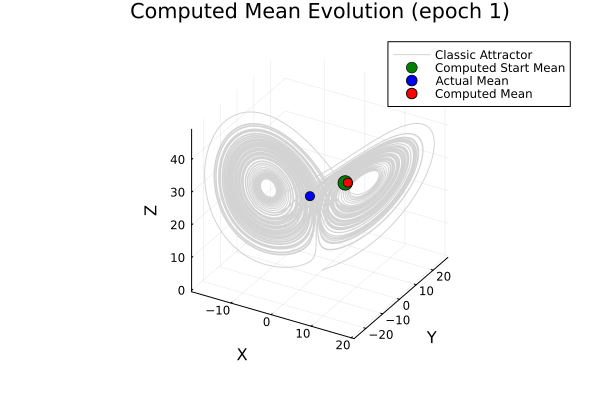

In [30]:
using Plots

# Extract computed means at each epoch from training history
computed_means = [s.mean for s in result.stats_history]

# Prepare classic attractor for background
classic_traj = integrate(base_params, u0, tspan, dt)
actual_mean = [mean_x, mean_y, mean_z]

# Animation of mean evolution
anim = @animate for i in 1:length(computed_means)
    plot(
        classic_traj.u[:, 1], classic_traj.u[:, 2], classic_traj.u[:, 3];
        linecolor=:lightgray, linewidth=1, label="Classic Attractor", seriestype=:path3d,
        title="Computed Mean Evolution (epoch $i)",
        xlabel="X", ylabel="Y", zlabel="Z",
        legend=:topright, size=(600, 400)
    )
    scatter!(
    [init_mean_x], [init_mean_y], [init_mean_z];
    marker=:circle, markersize=8, markercolor=:green, label="Computed Start Mean"
    )
    scatter!([actual_mean[1]], [actual_mean[2]], [actual_mean[3]];
        markersize=5, markercolor=:blue, label="Actual Mean"
    )
    scatter!([computed_means[i][1]], [computed_means[i][2]], [computed_means[i][3]];
        markersize=5, markercolor=:red, label="Computed Mean"
    )
end

gif(anim, "img/computed_mean_evolution.gif", fps=10)